# Data Analysis
[Olist dataset](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

In [1]:
## python built-in modules
from pathlib import Path

## third party modules
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt

## loads specific package modules, which contain project settings
from client_segmentation.config import PROCESSED_DATA_DIR
from client_segmentation.config import RAW_DATA_DIR
from client_segmentation.config import INTERIM_DATA_DIR

2025-04-01 10:14:06.048 | INFO     | client_segmentation.config:<module>:11 - PROJ_ROOT path is: /home/gasobral/Meus Arquivos/data-science/client_segmentation


In [14]:
%matplotlib inline

In [2]:
## below there is a mapping of dtypes for every column of each csv file
## data_mapping is a dictionary which its key = csv file and
## value = dict (dtype mapping, where key = column and value = dtype)
product_category_name_translation_map = {
    'product_category_name' : 'string',
    'product_category_name_english' : 'string'
}

olist_sellers_dataset_map = {
    'seller_id': 'string',
    'seller_zip_code_prefix': 'int64',
    'seller_city': 'string',
    'seller_state': 'string'
}

olist_geolocation_dataset_map = {
    'geolocation_zip_code_prefix': 'int64',
    'geolocation_lat': 'float64',
    'geolocation_lng': 'float64',
    'geolocation_city': 'string',
    'geolocation_state': 'string'
}

olist_products_dataset_map = {
    'product_id': 'string',
    'product_category_name': 'string',
    'product_name_lenght': 'float64',
    'product_description_lenght': 'float64',
    'product_photos_qty':  'float64',
    'product_weight_g': 'float64',
    'product_length_cm': 'float64',
    'product_height_cm': 'float64',
    'product_width_cm': 'float64'
}

olist_order_items_dataset_map = {
    'order_id': 'string',
    'order_item_id': 'int64',
    'product_id': 'string',
    'seller_id': 'string',
    'shipping_limit_date': 'object',
    'price': 'float64',
    'freight_value': 'float64'
}

olist_order_payments_dataset_map = {
    'order_id': 'string',
    'payment_sequential': 'int64',
    'payment_type': 'string',
    'payment_installments': 'int64',
    'payment_value': 'float64',
}

olist_orders_dataset_map = {
    'order_id': 'string',
    'customer_id': 'string',
    'order_status': 'string',
    'order_purchase_timestamp': 'object',
    'order_approved_at': 'object',
    'order_delivered_carrier_date': 'object',
    'order_delivered_customer_date': 'object',
    'order_estimated_delivery_date': 'object'
}

olist_order_reviews_dataset_map = {
    'review_id': 'string',
    'order_id': 'string',
    'review_score': 'int64',
    'review_comment_title': 'string',
    'review_comment_message': 'string',
    'review_creation_date': 'object',
    'review_answer_timestamp': 'object'
}

olist_customers_dataset_map = {
     'customer_id': 'string',
     'customer_unique_id': 'string',
     'customer_zip_code_prefix': 'int64',
     'customer_city': 'string',
     'customer_state': 'string'
}

data_mapping = {
    'product_category_name_translation': product_category_name_translation_map,
    'olist_sellers_dataset': olist_sellers_dataset_map,
    'olist_geolocation_dataset': olist_geolocation_dataset_map,
    'olist_products_dataset': olist_products_dataset_map,
    'olist_order_items_dataset': olist_order_items_dataset_map,
    'olist_order_payments_dataset': olist_order_payments_dataset_map,
    'olist_orders_dataset': olist_orders_dataset_map,
    'olist_order_reviews_dataset': olist_order_reviews_dataset_map,
    'olist_customers_dataset': olist_customers_dataset_map
}

In [9]:
def univariate_categorical(categorical_vars: pd.DataFrame,
                          num_rows: int = 5):
    """
    Perform univariate analysis for categorial variables.

    Arguments
    ---------
    categorical_vars: a data frame with only categorical variables.

    num_rows: number of distinct categories to be plotted in barplot.
    """

    ## check if there is any categorial variable for processing
    if categorical_vars.shape[1] > 0:
        for cat_var in categorical_vars:
            ## obtain the number of distinct categories
            unique_values = categorical_vars[cat_var].nunique()
            print(f'Number of unique values for {cat_var}: '
                  f'{unique_values}')

            ## if categories values are unique, then we do not create a
            ## bar plot for them
            if unique_values == categorical_vars.shape[0] or \
            "id" in cat_var:
                print(f'We are not creating a bar plot for the '
                      f'variable {cat_var},\nbecause all values are '
                      f'unique or its name contains the string id.\n')

            else:
                unique_values_count = categorical_vars[cat_var].value_counts()
                print(unique_values_count)
                fig, ax = plt.subplots(figsize=(16, 8))

                ## limting the number of categories in bar plot
                unique_values_count = unique_values_count.head(num_rows)

                ax.bar(unique_values_count.index,
                       unique_values_count.values)
                ax.set_title(f'Bar plot for {cat_var}')
                plt.show()
    else:
        print("There is no categorical variables.")

In [30]:
## TODO: fazer a análise univariada das variáveis numéricas
def univariate_numerical(numerical_vars):
    """
    Perform univariate analysis for numerical variables.
    """

    if numerical_vars.shape[1] > 0:
        print(numerical_vars.describe().T, end='\n\n')
        print(f'Skewness for each column\n'
              f'{numerical_vars.skew().T}\n')
        print(f'Kurtosis for each column\n'
              f'{numerical_vars.kurt().T}\n')

        ## TODO: plot histograma
        fig, axes = plt.subplots(numerical_vars.shape[1],
                                 1,
                                 squeeze=False,
                                 figsize=(16,8))
        axes = axes.ravel()

        for i, col in enumerate(numerical_vars.columns):
            print(i, col)

        ##       plot boxplot

    else:
        print('There is no numerical variables to analyze.')

In [4]:
def data_aquisition(file_path: Path,
                    data_mapping: dict) -> pd.DataFrame:
    """
    Given a file path, reads a dataset and return a data frame.
    
    Arguments
    ---------
    file_path: a file path for a csv file.
    
    data_mapping: a dictionary with a mapping, which tells type of data
                  for each column of csv file.

    Return
    ------
    A data frame with the data loaded from csv file.
    """

    ## create file without file extention (suffix) in order to
    ## obtain the date mapping for dataset columns 
    name_suffixless = file_path.name.split('.')[0]
    dataset = pd.read_csv(file_path,
                          dtype=data_mapping[name_suffixless],
                          date_format="%Y-%m-%d %H:%M:%S")

    ## creates a list only with the columns which contain data on
    ## their name
    date_columns = [col for col in dataset.columns
                    if "date" in col or
                    "time" in col or
                    "order_approved_at" in col]

    if len(date_columns) != 0:
        for col in date_columns:
            dataset[col] = pd.to_datetime(dataset[col],
                                          format="%Y-%m-%d %H:%M:%S")
    else:
        print("Dataset has no columns which contain date!"
              " No parsing required.")

    return dataset

Preliminary analysis of product_category_name_translation.csv.
Dataset has no columns which contain date! No parsing required.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     string
 1   product_category_name_english  71 non-null     string
dtypes: string(2)
memory usage: 1.2 KB
None

First 5 lines of the data set.
    product_category_name product_category_name_english
0            beleza_saude                 health_beauty
1  informatica_acessorios         computers_accessories
2              automotivo                          auto
3         cama_mesa_banho                bed_bath_table
4        moveis_decoracao               furniture_decor

Number of null values.
product_category_name            0.0
product_category_name_english    0.0
dtype: float64

Number of

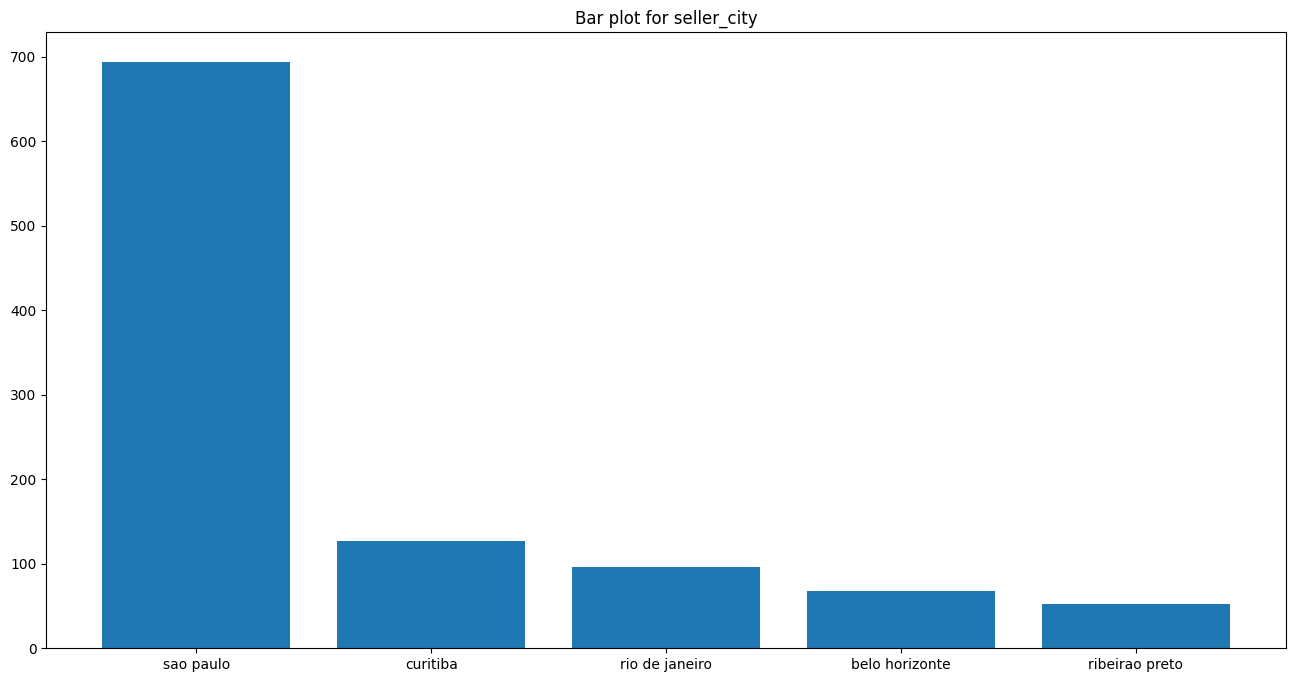

Number of unique values for seller_state: 23
seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
RN       5
MS       5
MT       4
RO       2
SE       2
PI       1
AC       1
MA       1
AM       1
PA       1
Name: count, dtype: Int64


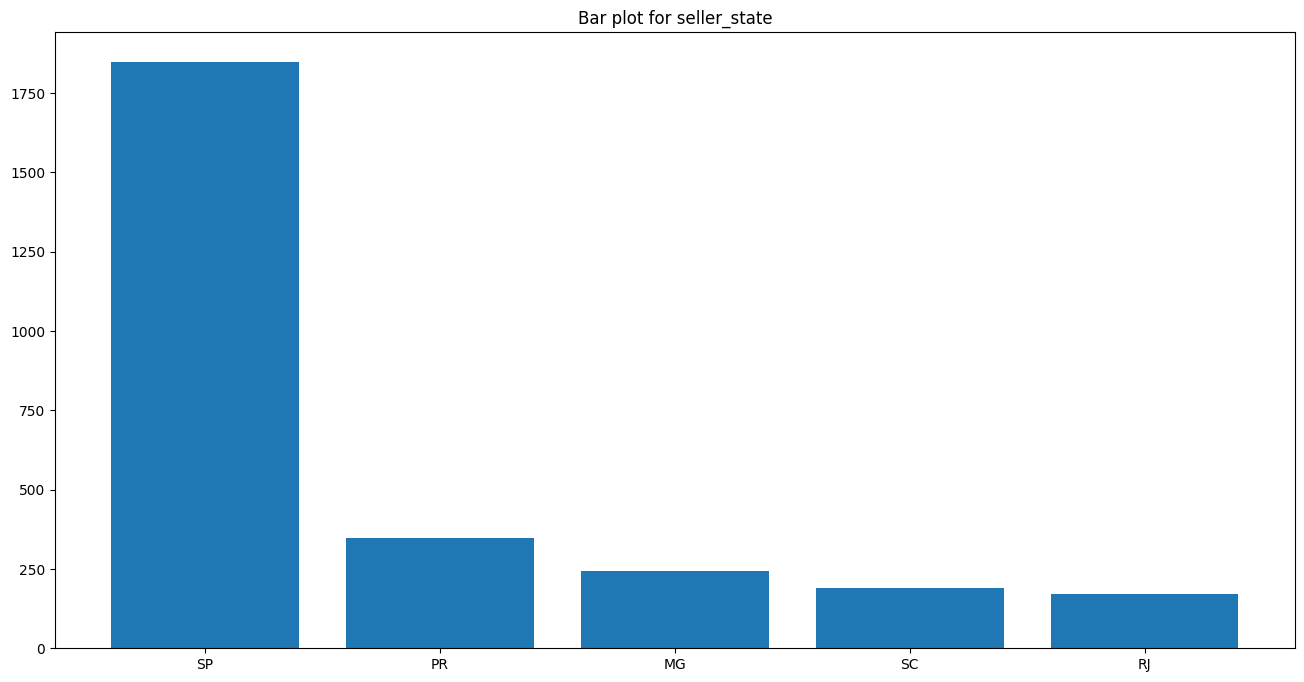

Numerical Variables
                         count          mean          std     min     25%  \
seller_zip_code_prefix  3095.0  32291.059451  32713.45383  1001.0  7093.5   

                            50%      75%      max  
seller_zip_code_prefix  14940.0  64552.5  99730.0  

Skewness for each column
seller_zip_code_prefix    0.916092
dtype: float64

Kurtosis for each column
seller_zip_code_prefix   -0.858264
dtype: float64

0 seller_zip_code_prefix
----------------------------------------------------

Preliminary analysis of olist_geolocation_dataset.csv.
Dataset has no columns which contain date! No parsing required.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_l

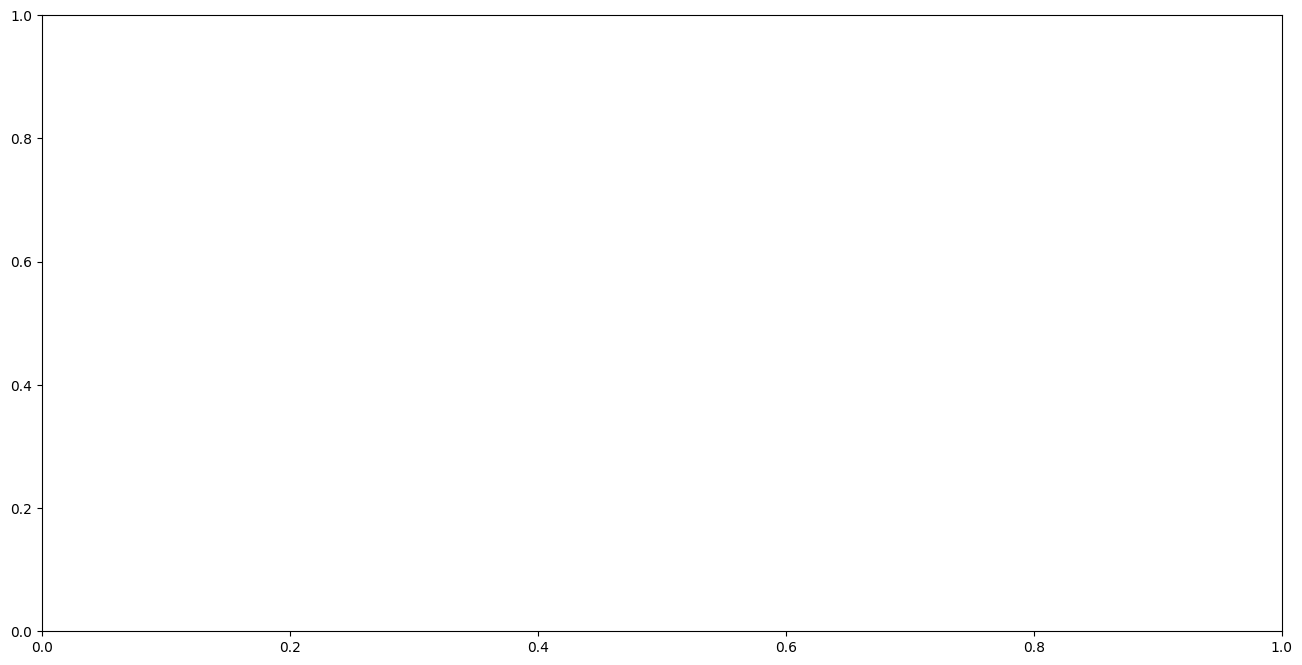

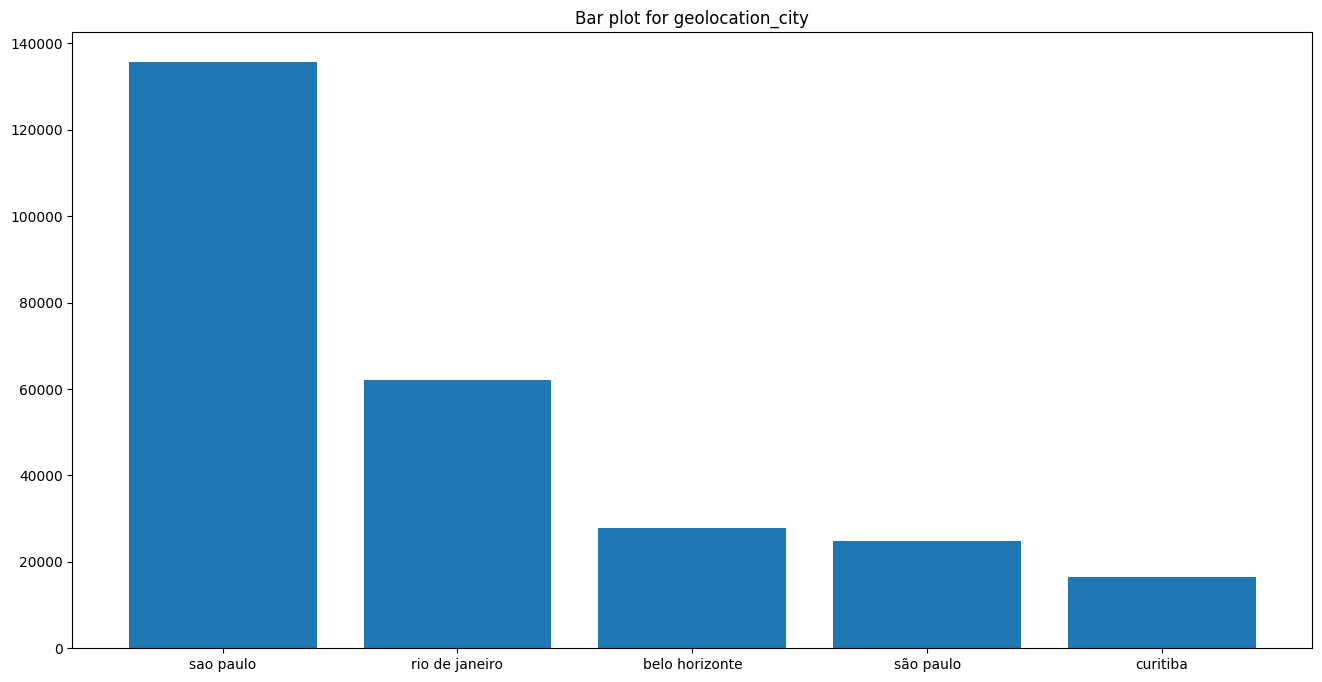

Number of unique values for geolocation_state: 27
geolocation_state
SP    404268
MG    126336
RJ    121169
RS     61851
PR     57859
SC     38328
BA     36045
GO     20139
ES     16748
PE     16432
DF     12986
MT     12031
CE     11674
PA     10853
MS     10431
MA      7853
PB      5538
RN      5041
PI      4549
AL      4183
TO      3576
SE      3563
RO      3478
AM      2432
AC      1301
AP       853
RR       646
Name: count, dtype: Int64


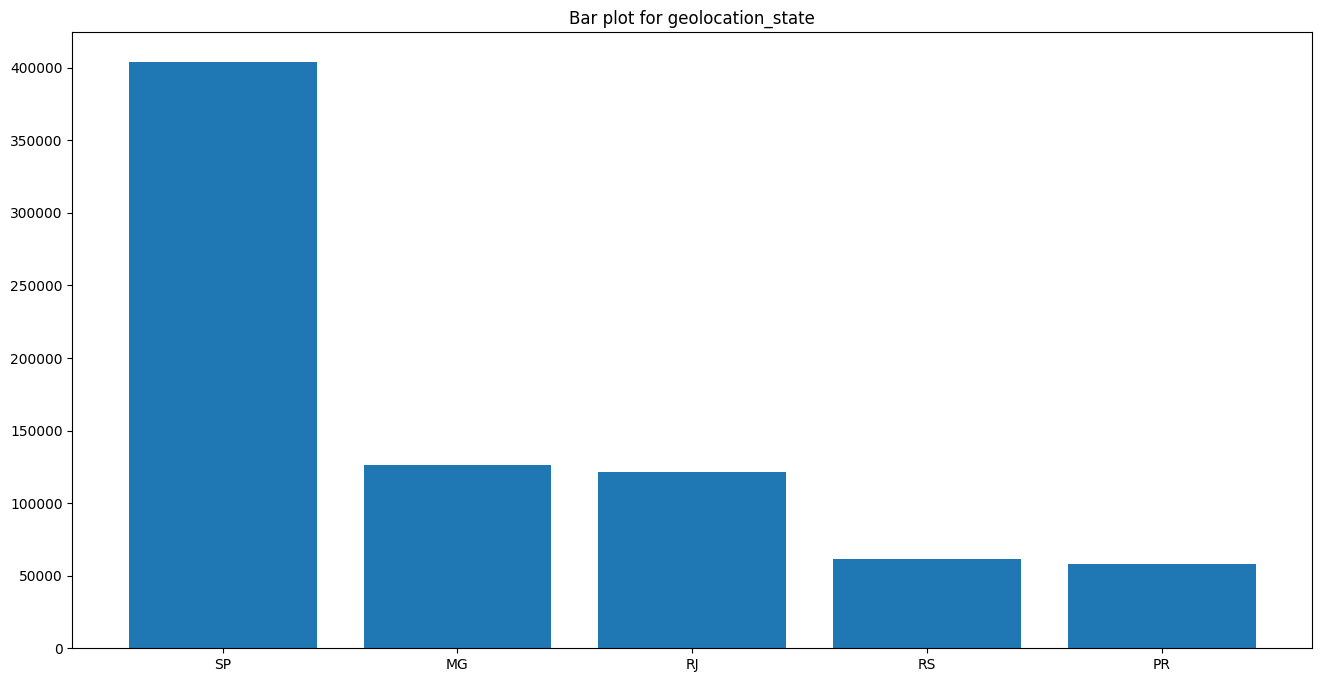

Numerical Variables
                                 count          mean           std  \
geolocation_zip_code_prefix  1000163.0  36574.166466  30549.335710   
geolocation_lat              1000163.0    -21.176153      5.715866   
geolocation_lng              1000163.0    -46.390541      4.269748   

                                     min           25%           50%  \
geolocation_zip_code_prefix  1001.000000  11075.000000  26530.000000   
geolocation_lat               -36.605374    -23.603546    -22.919377   
geolocation_lng              -101.466766    -48.573172    -46.637879   

                                      75%           max  
geolocation_zip_code_prefix  63504.000000  99990.000000  
geolocation_lat                -19.979620     45.065933  
geolocation_lng                -43.767709    121.105394  

Skewness for each column
geolocation_zip_code_prefix    0.694494
geolocation_lat                1.565147
geolocation_lng               -0.102417
dtype: float64

Kurtosis for eac

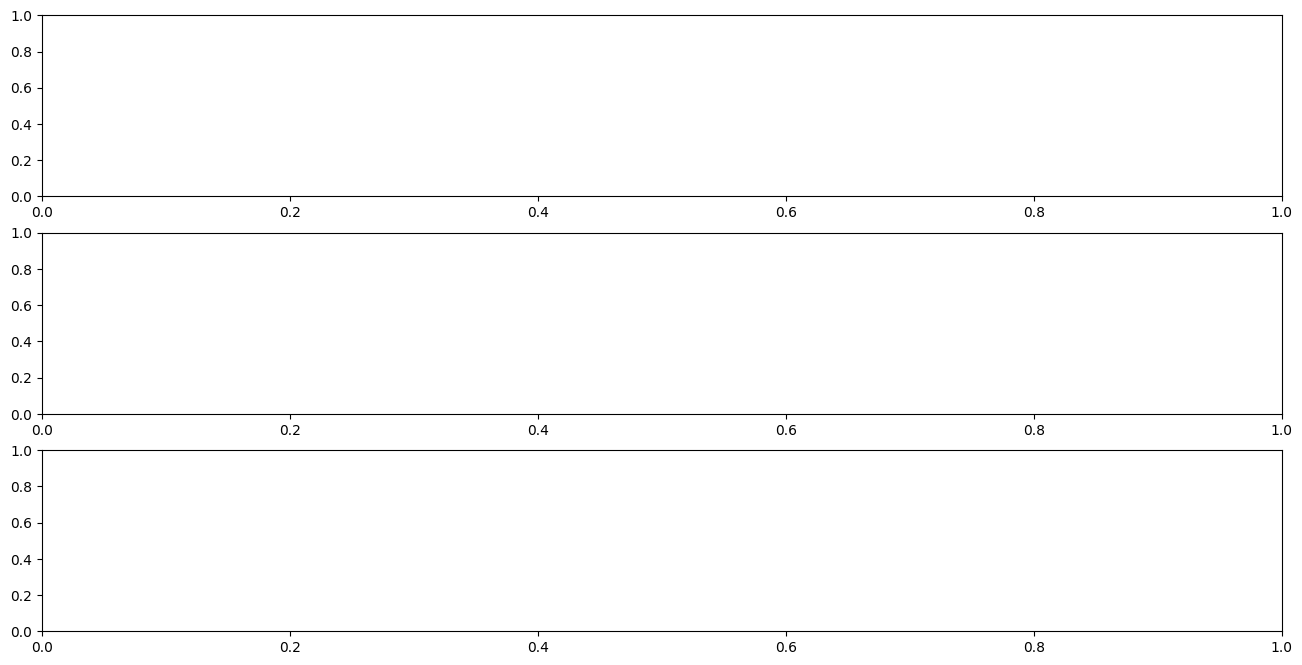

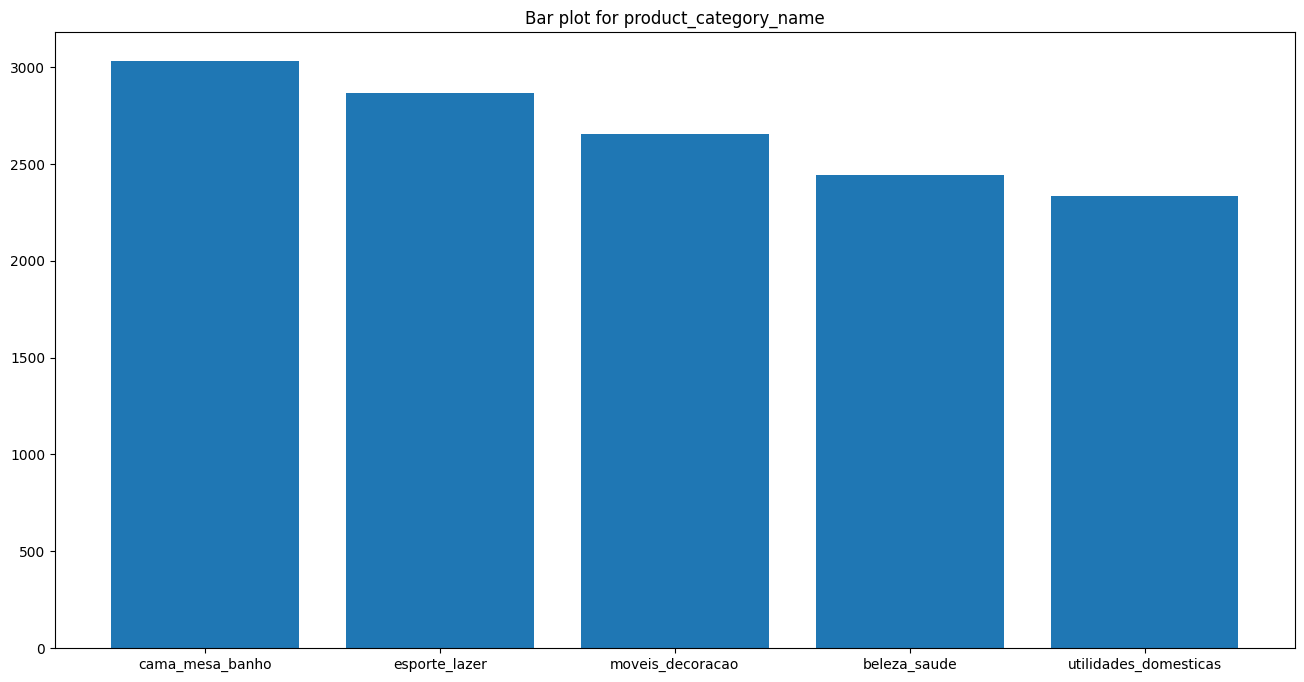

Numerical Variables
                              count         mean          std  min    25%  \
product_name_lenght         32341.0    48.476949    10.245741  5.0   42.0   
product_description_lenght  32341.0   771.495285   635.115225  4.0  339.0   
product_photos_qty          32341.0     2.188986     1.736766  1.0    1.0   
product_weight_g            32949.0  2276.472488  4282.038731  0.0  300.0   
product_length_cm           32949.0    30.815078    16.914458  7.0   18.0   
product_height_cm           32949.0    16.937661    13.637554  2.0    8.0   
product_width_cm            32949.0    23.196728    12.079047  6.0   15.0   

                              50%     75%      max  
product_name_lenght          51.0    57.0     76.0  
product_description_lenght  595.0   972.0   3992.0  
product_photos_qty            1.0     3.0     20.0  
product_weight_g            700.0  1900.0  40425.0  
product_length_cm            25.0    38.0    105.0  
product_height_cm            13.0    21.0    

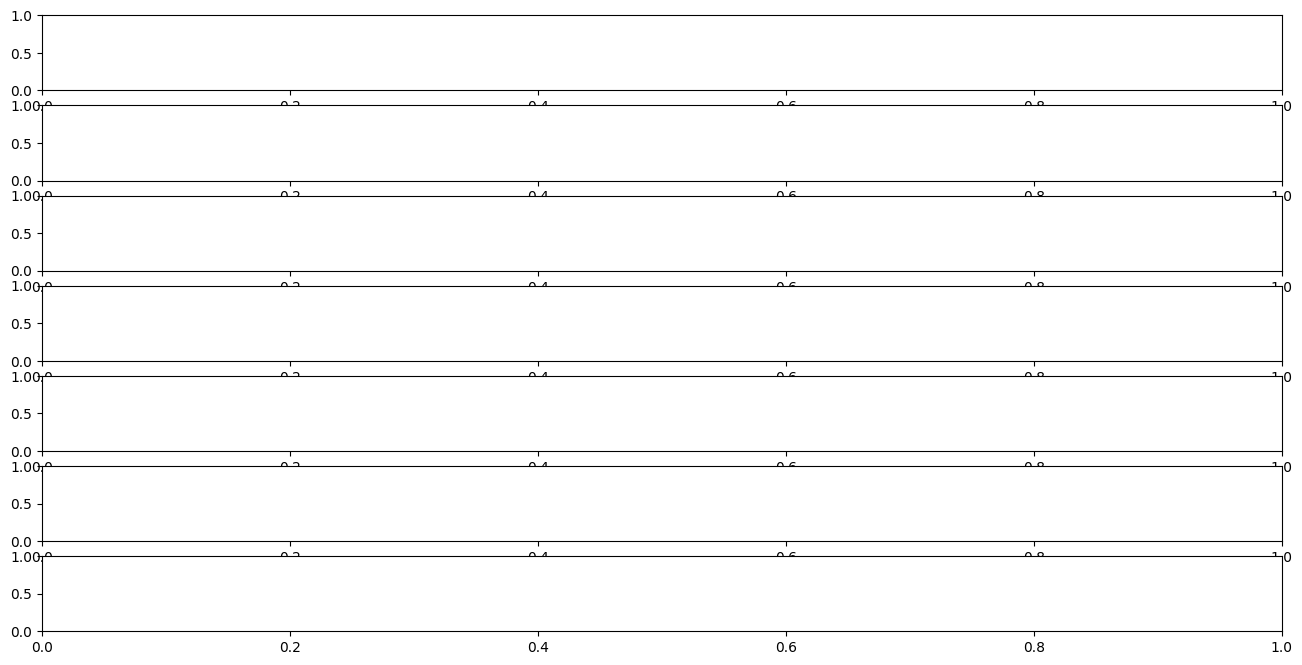

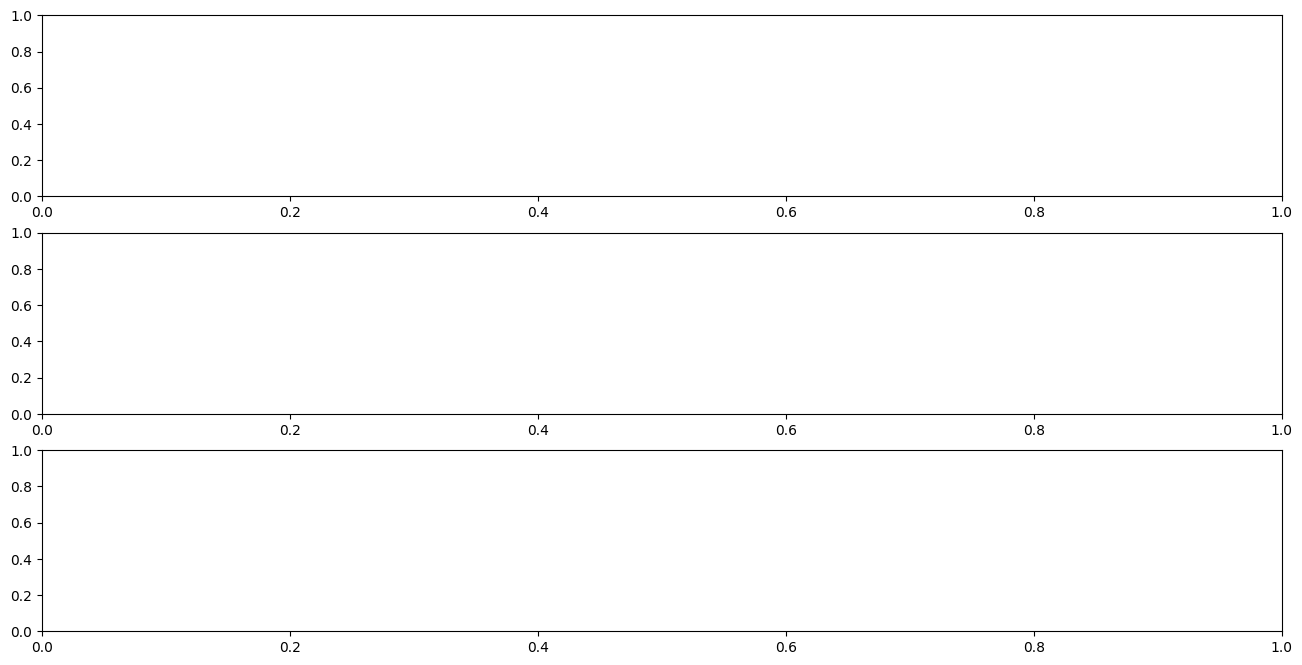

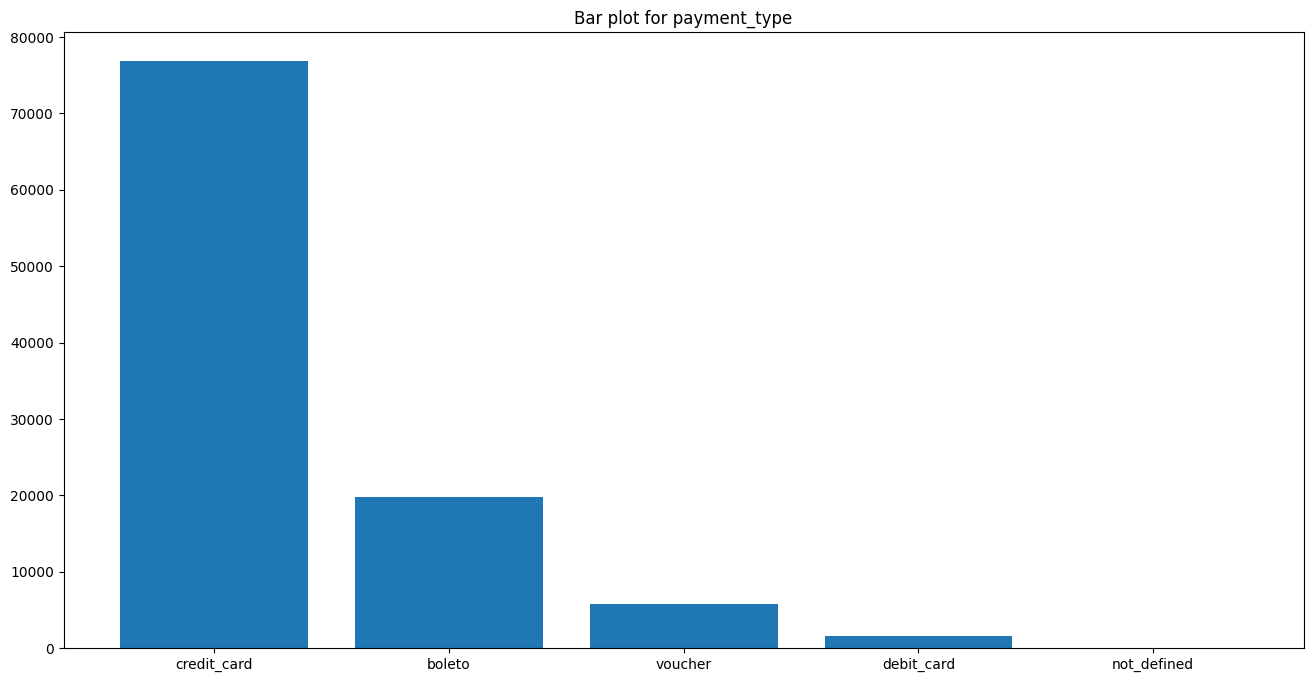

Numerical Variables
                         count        mean         std  min    25%    50%  \
payment_sequential    103886.0    1.092679    0.706584  1.0   1.00    1.0   
payment_installments  103886.0    2.853349    2.687051  0.0   1.00    1.0   
payment_value         103886.0  154.100380  217.494064  0.0  56.79  100.0   

                           75%       max  
payment_sequential      1.0000     29.00  
payment_installments    4.0000     24.00  
payment_value         171.8375  13664.08  

Skewness for each column
payment_sequential      16.180065
payment_installments     1.655074
payment_value            9.254010
dtype: float64

Kurtosis for each column
payment_sequential      370.593809
payment_installments      2.550048
payment_value           241.828442
dtype: float64

0 payment_sequential
1 payment_installments
2 payment_value
----------------------------------------------------

Preliminary analysis of olist_orders_dataset.csv.
<class 'pandas.core.frame.DataFrame'>
RangeIn

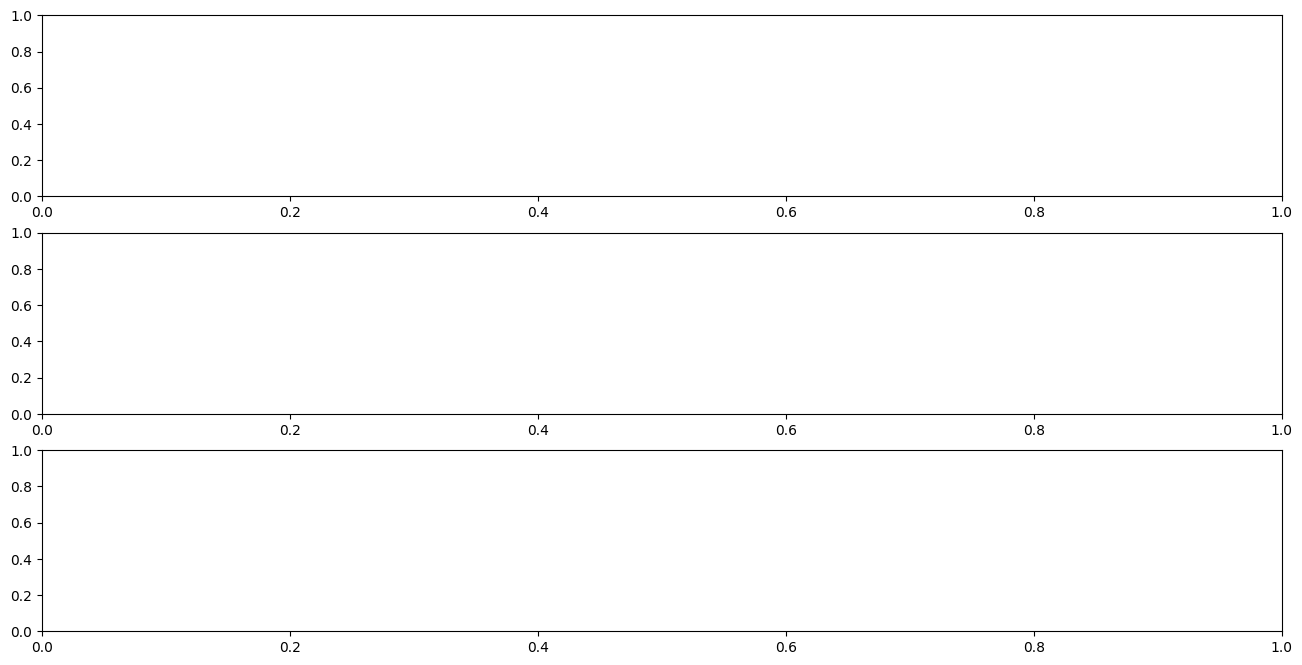

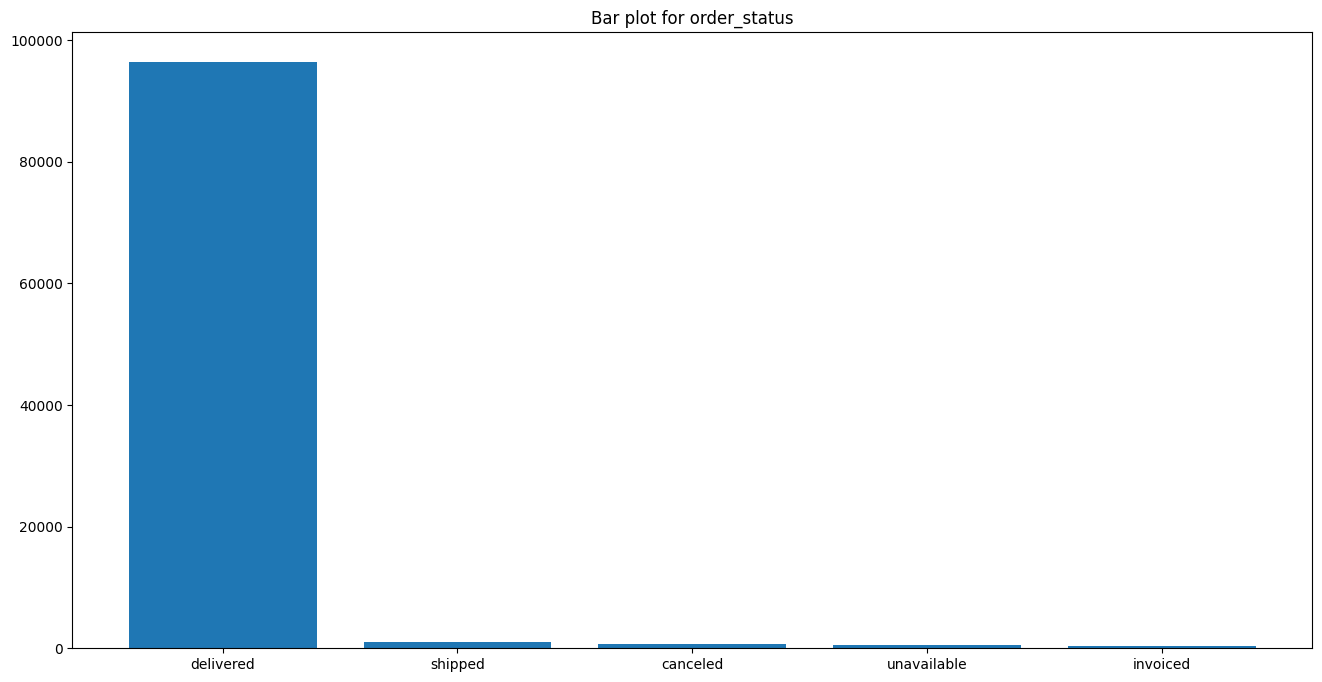

Numerical Variables
There is no numerical variables to analyze.
----------------------------------------------------

Preliminary analysis of olist_order_reviews_dataset.csv.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  string        
 1   order_id                 99224 non-null  string        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  string        
 4   review_comment_message   40977 non-null  string        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), string(4)
memory usage: 5.3 MB
None

First 5 lines of the data set.
                          review_id                          or

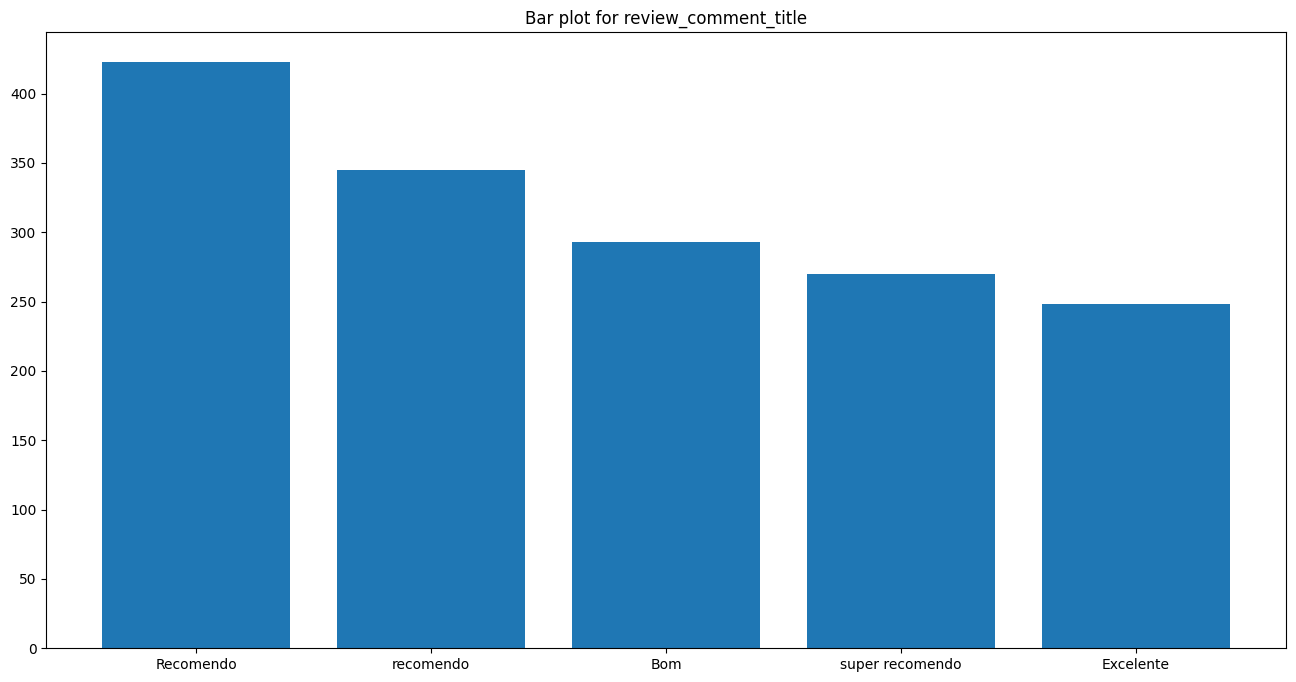

Number of unique values for review_comment_message: 36159
review_comment_message
Muito bom                                                                                                                                                        230
Bom                                                                                                                                                              189
muito bom                                                                                                                                                        122
bom                                                                                                                                                              107
Recomendo                                                                                                                                                        100
                                                                                              

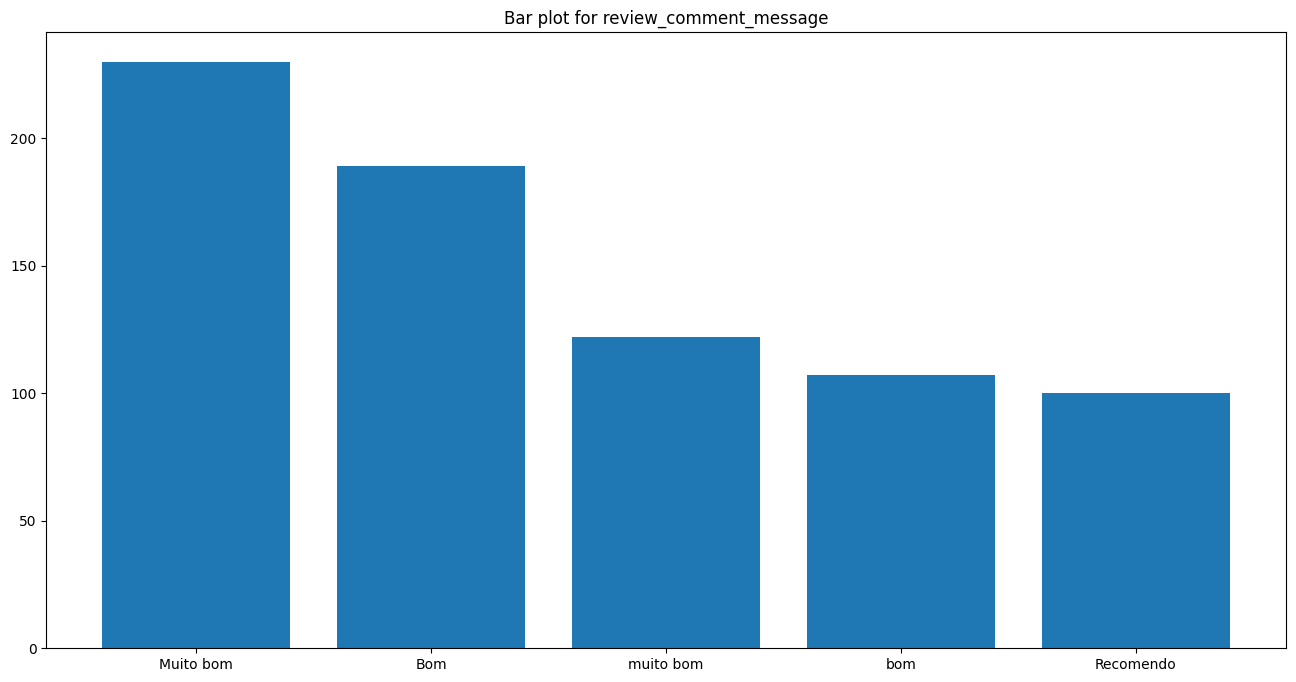

Numerical Variables
                count      mean       std  min  25%  50%  75%  max
review_score  99224.0  4.086421  1.347579  1.0  4.0  5.0  5.0  5.0

Skewness for each column
review_score   -1.364386
dtype: float64

Kurtosis for each column
review_score    0.507653
dtype: float64

0 review_score
----------------------------------------------------

Preliminary analysis of olist_customers_dataset.csv.
Dataset has no columns which contain date! No parsing required.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  string
 1   customer_unique_id        99441 non-null  string
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  string
 4   customer_state            99441 non-null  string
dtypes: int64(1), string(4)
memory usage:

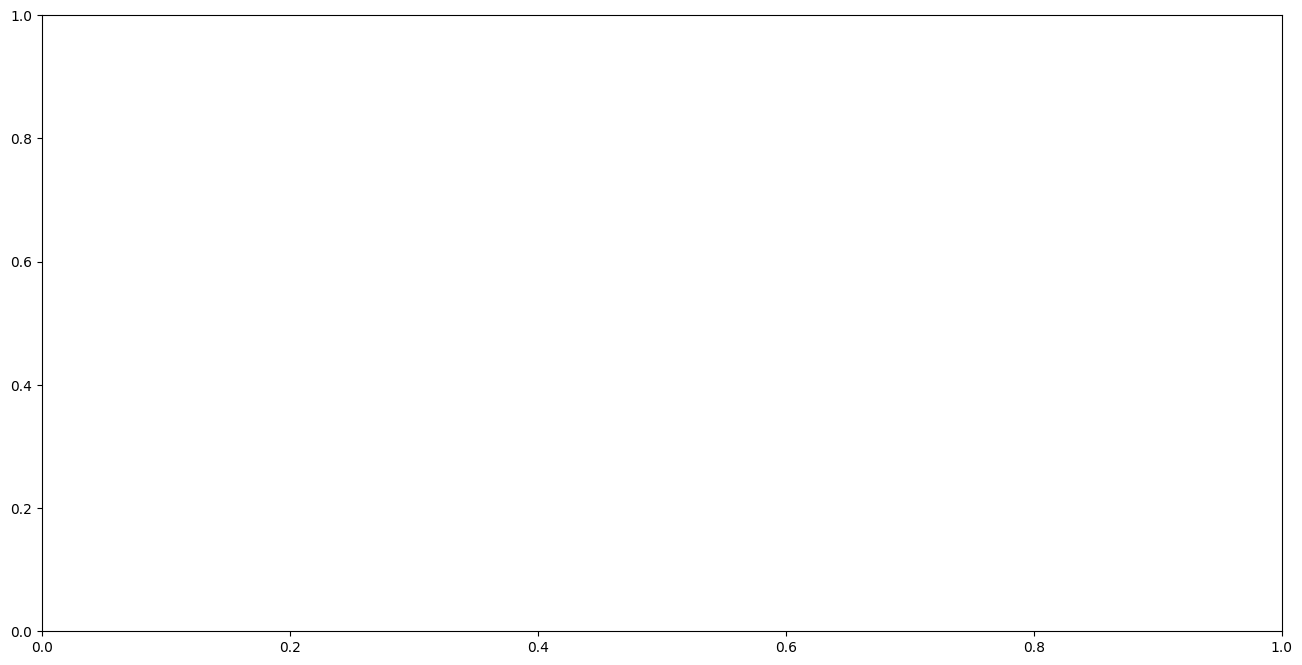

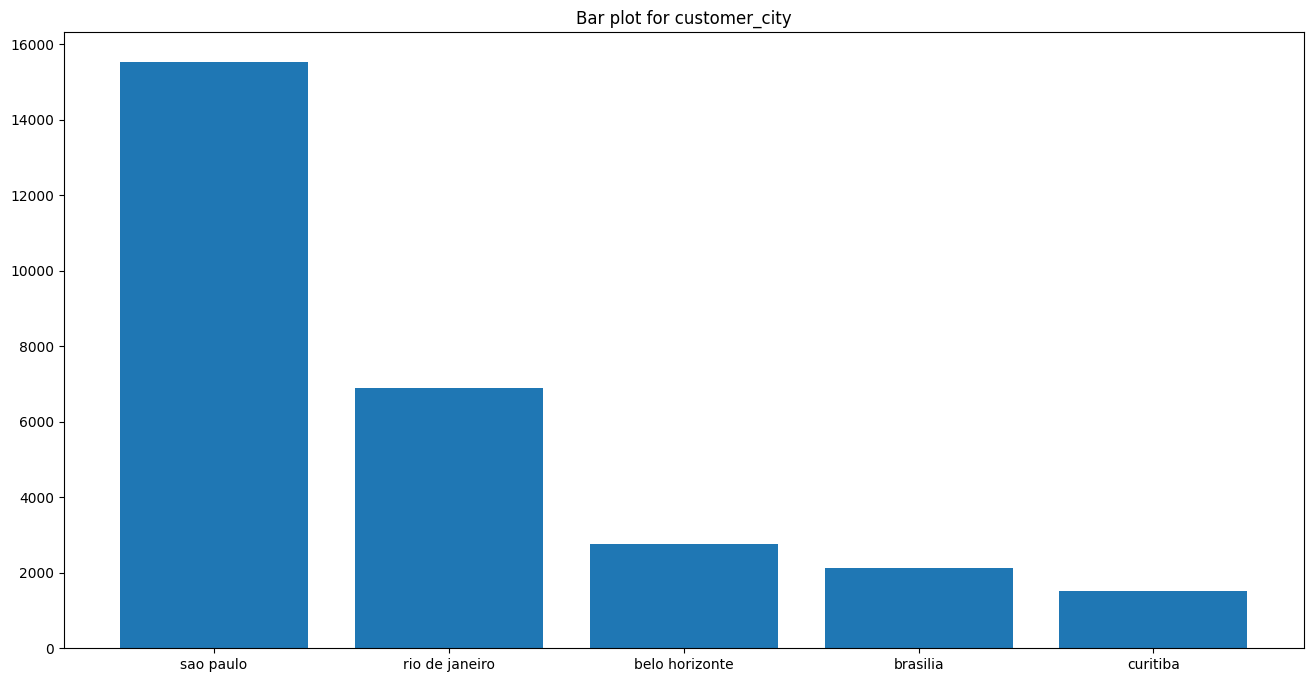

Number of unique values for customer_state: 27
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: Int64


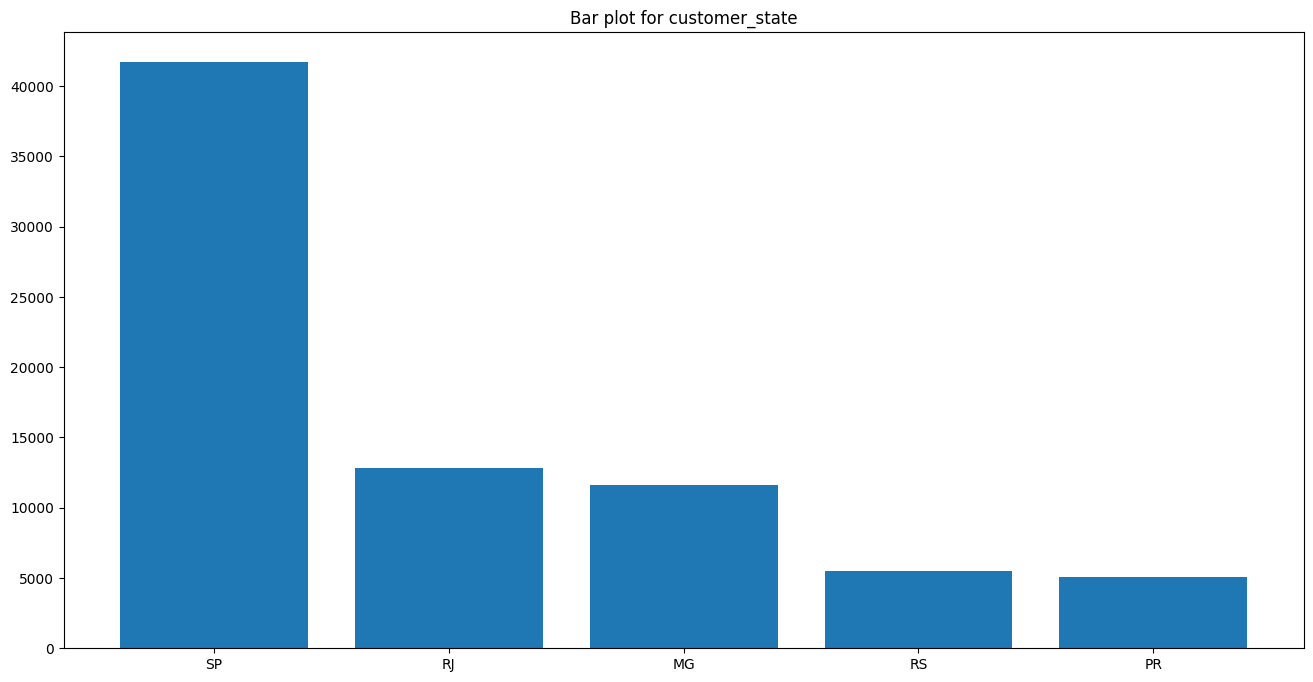

Numerical Variables
                            count          mean           std     min  \
customer_zip_code_prefix  99441.0  35137.474583  29797.938996  1003.0   

                              25%      50%      75%      max  
customer_zip_code_prefix  11347.0  24416.0  58900.0  99990.0  

Skewness for each column
customer_zip_code_prefix    0.779025
dtype: float64

Kurtosis for each column
customer_zip_code_prefix   -0.788204
dtype: float64

0 customer_zip_code_prefix
----------------------------------------------------



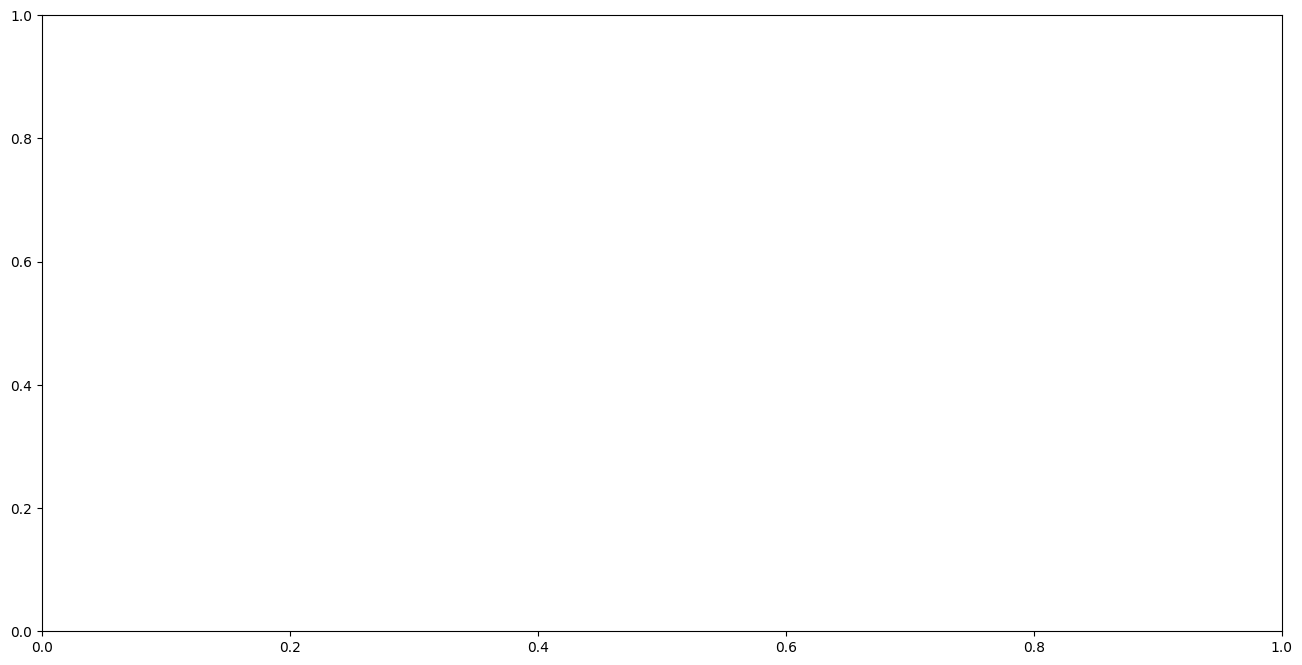

In [31]:
## goes through the datasets at INTERIM_DATA_DIR directory
## and perform preliminary analysis, which includes:
## - check which type of data was loaded
## - check for null values
## - check for duplicated rows
## - univariate analysis for numerical and categorical data
for curr_file in INTERIM_DATA_DIR.iterdir():
    ## if below is used to ignore hidden files
    if curr_file.name.startswith('.') == False:
        print(f'Preliminary analysis of {curr_file.name}.')
        dataset = data_aquisition(INTERIM_DATA_DIR / curr_file.name,
                                  data_mapping)

        ## provide initial information of loaded dataset
        print(dataset.info(), end='\n\n')
        print(f'First 5 lines of the data set.\n'
              f'{dataset.head(5)}\n')
        print(f'Number of null values.\n'
              f'{dataset.isna().sum() / dataset.shape[0] * 100}\n')
        print(f'Number of duplicated rows: '
              f'{dataset.duplicated().sum()}\n')

        ## perform univariate analysis for numerical and
        ## categorical variables
        print('Univariate Analysis\nCategorial Variables')
        categorical_vars = dataset.select_dtypes(include=['string'])
        univariate_categorical(categorical_vars)
        ## TODO: fazer a análise univariada das variáveis numéricas
        print('Numerical Variables')
        numerical_vars = dataset.select_dtypes(include=['number'])
        univariate_numerical(numerical_vars)
        print(end='----------------------------------------------------\n\n')

The file 'product_category_name_translation.csv' contains unique names
for product category in brazilian portuguese and their respective
translation in english. No null or duplicated values were found.

### Data dictionary
| Column | Type | Description |
| :--- | :--- | :--- |
| product_category_name | string | name of a product category in portugese |
| product_category_name_english | string | name of a product category in  english |

### Data dictionary
| Column | Type | Description |
| :--- | :--- | :--- |
| seller | object | an id from a seller (for example 3442f8959a84dea7ee197c632cb2df15) |
| seller_zip_code_prefix | int64 | a number which identifies a zip code |
| seller city | string | the city from the seller |
| seller_state | string | the state from the seller |